# LC / FC Analysis — 수치 입력 틀

- 고정: seed = 2026, `f = 20%` (selected data ratio)
- 변동: `r ∈ {1, 5, 10, 15, 20, 25, 30}%` (eigen rank as % of `num_train_dp`)
- 대상 데이터셋 (괄호 안은 `num_train_dp`, 그래프/표에 명시):
  - `sst2` (5000), `qqp` (5000), `mnli` (5000), `ag_news` (5000), `mr` (5000)
  - `mrpc` (3668), `rte` (2490)
- 각 `(dataset, r)` 마다 accuracy / LC / FC 입력
- 각 `r` 마다 cross-dataset Pearson / Spearman 상관계수 입력

> 이 노트북은 **수치 입력용 스켈레톤**입니다. 분석/시각화 코드는 아직 포함하지 않습니다.
>
> 각 `# TODO` 옆에 `[type]` 을 표기했습니다:
> - `[int]`  : ×10000 정수 하나 (예: `8234`)
> - `[float]`: 스칼라 실수 하나 (예: `0.7123`)
> - `[dict]` : 키가 고정된 dict (예: `{"LC": 0.x, "FC": 0.y, ...}`)

In [1]:
import numpy as np
import pandas as pd

## 1. 실험 설정 (Experiment Configuration)

In [2]:
SEED = 2026
F_PERCENT = 30  # selected data ratio (%)
R_VALUES = [1, 5, 10, 15, 20, 25, 30]  # eigen rank as % of num_train_dp

# dataset -> num_train_dp (그래프/표 label 용으로도 사용)
NUM_TRAIN_DP = {
    "sst2":    5000,
    "qqp":     5000,
    "mnli":    5000,
    "ag_news": 5000,
    "mr":      5000,
    "mrpc":    3668,
    "rte":     2490,
}
DATASETS = list(NUM_TRAIN_DP.keys())

## 2. 데이터셋별 Base Accuracy 및 inv@f=20% Accuracy 입력

- `acc_base`: `task_base_accuracy.py` 로 구한 inv-mode accuracy @ 0% selected (×10000 정수 그대로 넣기)
- `ACC_INV_F30`: `task_data_selection.py` inv-top 결과에서 f=20% 해당값 (×10000 정수)

In [3]:
# acc_base    : inv-mode accuracy @ 0% selected data (×10000 정수)
# ACC_INV_F30 : inv-top accuracy @ f=20% selected data (×10000 정수)
ACC_BASE = {
    "sst2":    4908,  # TODO [int]
    "qqp":     6180,  # TODO [int]
    "mnli":    3720,  # TODO [int]
    "ag_news": 2350,  # TODO [int]
    "mr":      5030,  # TODO [int]
    "mrpc":    3162,  # TODO [int]
    "rte":     5271,  # TODO [int]
}

ACC_INV_F30 = {
    "sst2":    8291,  # TODO [int]
    "qqp":     8130,  # TODO [int]
    "mnli":    6500,  # TODO [int]
    "ag_news": 9020,  # TODO [int]
    "mr":      8670,  # TODO [int]
    "mrpc":    7917,  # TODO [int]
    "rte":     8773,  # TODO [int]
}

## 3. `(dataset, r)` 별 Eigen@f=20% Accuracy / LC / FC 입력

- `acc_eigen_f30`: `task_data_selection.py` eigen-top 결과에서 f=20% 해당값 (×10000 정수)
- `LC` : rank-r label concentration (스칼라, 0~1)
- `FC` : rank-r feature concentration (스칼라, 0~1)

In [4]:
# PER_RANK[ds][r] = {"acc_eigen_f30": int, "LC": float, "FC": float}
#   acc_eigen_f30 : ×10000 정수
#   LC, FC        : 스칼라 실수 (0~1 범위)
def _empty_rank_dict():
    return {r: {"acc_eigen_f30": None, "LC": None, "FC": None} for r in R_VALUES}

PER_RANK = {ds: _empty_rank_dict() for ds in DATASETS}
[1111, 1111, 1111, 1111, 1111, 1111, 1111, 1111, 1111, 1111]
[6354, 6679, 6968, 7292, 7653, 7437, 7762, 8087, 8014, 7906, 
 8087, 8087, 8231, 8484, 8520, 8484, 8412, 8592, 8700, 8700, 
 8700, 8773, 8736, 8736, 8773, 8700, 8736, 8773, 8736, 8773, 8736, 8736, 8809, 8773, 8845, 8845, 8809, 8845, 8881, 8845, 8845, 8881, 8773, 8773, 8773, 8809, 8809, 8881, 8845, 8953, 8809, 8989, 8953, 8989, 8881, 8953, 8989, 9025, 9025, 8989, 8881, 8917, 8953, 8953, 8881, 8809, 8773, 8773, 8736, 8736, 8809, 8773, 8700, 8845, 8773, 8664, 8664, 8484, 8520, 8484, 8412, 8375, 8267, 8303, 8195, 8267, 8123, 7978, 8014, 7834, 7870, 7870, 7653, 7545, 7473, 7148, 6787, 6679, 6137, 5523]

# ---- sst2 (num_train_dp = 5000) ----
PER_RANK["sst2"][1]  = {"acc_eigen_f30": 8314, "LC": 4.9284969336e-01, "FC": 6.9897817739e-01}  # TODO [dict: int, float, float]
PER_RANK["sst2"][5]  = {"acc_eigen_f30": 8498, "LC": 5.6353978665e-01, "FC": 8.0885431003e-01}  # TODO [dict: int, float, float]
PER_RANK["sst2"][10] = {"acc_eigen_f30": 8555, "LC": 6.1028736367e-01, "FC": 8.5634610961e-01}  # TODO [dict: int, float, float]
PER_RANK["sst2"][15] = {"acc_eigen_f30": 8567, "LC": 6.4920324721e-01, "FC": 8.8420688577e-01}  # TODO [dict: int, float, float]
PER_RANK["sst2"][20] = {"acc_eigen_f30": 8624, "LC": 6.8095054179e-01, "FC": 9.0395031918e-01}  # TODO [dict: int, float, float]
PER_RANK["sst2"][25] = {"acc_eigen_f30": 8681, "LC": 7.0936166230e-01, "FC": 9.1919687413e-01}  # TODO [dict: int, float, float]
PER_RANK["sst2"][30] = {"acc_eigen_f30": 8670, "LC": 7.3442524328e-01, "FC": 9.3155073168e-01}  # TODO [dict: int, float, float]

# ---- qqp (num_train_dp = 5000) ----
PER_RANK["qqp"][1]  = {"acc_eigen_f30": 7370, "LC": 2.3935292090e-01, "FC": 8.7196156477e-01}  # TODO [dict: int, float, float]
PER_RANK["qqp"][5]  = {"acc_eigen_f30": 7620, "LC": 3.3775996198e-01, "FC": 9.2929183308e-01}  # TODO [dict: int, float, float]
PER_RANK["qqp"][10] = {"acc_eigen_f30": 7840, "LC": 4.0059892446e-01, "FC": 9.5055062197e-01}  # TODO [dict: int, float, float]
PER_RANK["qqp"][15] = {"acc_eigen_f30": 7910, "LC": 4.4569032512e-01, "FC": 9.6201209228e-01}  # TODO [dict: int, float, float]
PER_RANK["qqp"][20] = {"acc_eigen_f30": 7990, "LC": 4.8581546241e-01, "FC": 9.6965136076e-01}  # TODO [dict: int, float, float]
PER_RANK["qqp"][25] = {"acc_eigen_f30": 8060, "LC": 5.2131718926e-01, "FC": 9.7525683213e-01}  # TODO [dict: int, float, float]
PER_RANK["qqp"][30] = {"acc_eigen_f30": 8150, "LC": 5.5863394532e-01, "FC": 9.7961138210e-01}  # TODO [dict: int, float, float]

# ---- mnli (num_train_dp = 5000) ----
PER_RANK["mnli"][1]  = {"acc_eigen_f30": 5540, "LC": 1.5513144199e-01, "FC": 7.0118994939e-01}  # TODO [dict: int, float, float]
PER_RANK["mnli"][5]  = {"acc_eigen_f30": 6070, "LC": 2.5158896738e-01, "FC": 8.1223925452e-01}  # TODO [dict: int, float, float]
PER_RANK["mnli"][10] = {"acc_eigen_f30": 6270, "LC": 3.1981167012e-01, "FC": 8.5854069551e-01}  # TODO [dict: int, float, float]
PER_RANK["mnli"][15] = {"acc_eigen_f30": 6540, "LC": 3.7023518584e-01, "FC": 8.8547441064e-01}  # TODO [dict: int, float, float]
PER_RANK["mnli"][20] = {"acc_eigen_f30": 6510, "LC": 4.1677282228e-01, "FC": 9.0447133957e-01}  # TODO [dict: int, float, float]
PER_RANK["mnli"][25] = {"acc_eigen_f30": 6640, "LC": 4.6128037276e-01, "FC": 9.1906899545e-01}  # TODO [dict: int, float, float]
PER_RANK["mnli"][30] = {"acc_eigen_f30": 6580, "LC": 5.0913272146e-01, "FC": 9.3085824590e-01}  # TODO [dict: int, float, float]

# ---- ag_news (num_train_dp = 5000) ----
PER_RANK["ag_news"][1]  = {"acc_eigen_f30": 8760, "LC": 6.6643816950e-01, "FC": 7.7167634724e-01}  # TODO [dict: int, float, float]
PER_RANK["ag_news"][5]  = {"acc_eigen_f30": 8840, "LC": 7.3059051755e-01, "FC": 8.6987398544e-01}  # TODO [dict: int, float, float]
PER_RANK["ag_news"][10] = {"acc_eigen_f30": 8890, "LC": 7.6470325384e-01, "FC": 9.0641590216e-01}  # TODO [dict: int, float, float]
PER_RANK["ag_news"][15] = {"acc_eigen_f30": 8950, "LC": 7.8927007932e-01, "FC": 9.2577632808e-01}  # TODO [dict: int, float, float]
PER_RANK["ag_news"][20] = {"acc_eigen_f30": 8970, "LC": 8.0781146601e-01, "FC": 9.3873148935e-01}  # TODO [dict: int, float, float]
PER_RANK["ag_news"][25] = {"acc_eigen_f30": 8970, "LC": 8.2561778294e-01, "FC": 9.4838008457e-01}  # TODO [dict: int, float, float]
PER_RANK["ag_news"][30] = {"acc_eigen_f30": 9010, "LC": 8.4258303439e-01, "FC": 9.5603557014e-01}  # TODO [dict: int, float, float]

# ---- mr (num_train_dp = 5000) ----
PER_RANK["mr"][1]  = {"acc_eigen_f30": 8140, "LC": 4.3053101098e-01, "FC": 8.2437775341e-01}  # TODO [dict: int, float, float]
PER_RANK["mr"][5]  = {"acc_eigen_f30": 8360, "LC": 4.9878535044e-01, "FC": 8.9240578262e-01}  # TODO [dict: int, float, float]
PER_RANK["mr"][10] = {"acc_eigen_f30": 8570, "LC": 5.5247053288e-01, "FC": 9.2029643139e-01}  # TODO [dict: int, float, float]
PER_RANK["mr"][15] = {"acc_eigen_f30": 8610, "LC": 5.8875980680e-01, "FC": 9.3614073136e-01}  # TODO [dict: int, float, float]
PER_RANK["mr"][20] = {"acc_eigen_f30": 8690, "LC": 6.2010265727e-01, "FC": 9.4712611284e-01}  # TODO [dict: int, float, float]
PER_RANK["mr"][25] = {"acc_eigen_f30": 8580, "LC": 6.5052858855e-01, "FC": 9.5548573571e-01}  # TODO [dict: int, float, float]
PER_RANK["mr"][30] = {"acc_eigen_f30": 8620, "LC": 6.8022696699e-01, "FC": 9.6219020840e-01}  # TODO [dict: int, float, float]

# ---- mrpc (num_train_dp = 3668) ----
PER_RANK["mrpc"][1]  = {"acc_eigen_f30": 7034, "LC": 1.5026552577e-01, "FC": 6.8823466054e-01}  # TODO [dict: int, float, float]
PER_RANK["mrpc"][5]  = {"acc_eigen_f30": 7328, "LC": 2.4578321530e-01, "FC": 8.0058302280e-01}  # TODO [dict: int, float, float]
PER_RANK["mrpc"][10] = {"acc_eigen_f30": 7328, "LC": 3.1859073890e-01, "FC": 8.4828933846e-01}  # TODO [dict: int, float, float]
PER_RANK["mrpc"][15] = {"acc_eigen_f30": 7525, "LC": 3.7513611966e-01, "FC": 8.7667088856e-01}  # TODO [dict: int, float, float]
PER_RANK["mrpc"][20] = {"acc_eigen_f30": 7843, "LC": 4.2045157476e-01, "FC": 8.9693391813e-01}  # TODO [dict: int, float, float]
PER_RANK["mrpc"][25] = {"acc_eigen_f30": 7672, "LC": 4.6857966644e-01, "FC": 9.1268051325e-01}  # TODO [dict: int, float, float]
PER_RANK["mrpc"][30] = {"acc_eigen_f30": 7941, "LC": 5.0553871927e-01, "FC": 9.2550760843e-01}  # TODO [dict: int, float, float]

# ---- rte (num_train_dp = 2490) ----
PER_RANK["rte"][1]  = {"acc_eigen_f30": 6498, "LC": 4.4040916023e-02, "FC": 6.4113069322e-01}  # TODO [dict: int, float, float]
PER_RANK["rte"][5]  = {"acc_eigen_f30": 7690, "LC": 1.3512310817e-01, "FC": 7.6619983020e-01}  # TODO [dict: int, float, float]
PER_RANK["rte"][10] = {"acc_eigen_f30": 8195, "LC": 2.0620874691e-01, "FC": 8.2161796296e-01}  # TODO [dict: int, float, float]
PER_RANK["rte"][15] = {"acc_eigen_f30": 8556, "LC": 2.7114458668e-01, "FC": 8.5458455548e-01}  # TODO [dict: int, float, float]
PER_RANK["rte"][20] = {"acc_eigen_f30": 8412, "LC": 3.1542783680e-01, "FC": 8.7821360824e-01}  # TODO [dict: int, float, float]
PER_RANK["rte"][25] = {"acc_eigen_f30": 8700, "LC": 3.6050100406e-01, "FC": 8.9664371966e-01}  # TODO [dict: int, float, float]
PER_RANK["rte"][30] = {"acc_eigen_f30": 8700, "LC": 4.1286573357e-01, "FC": 9.1170739734e-01}  # TODO [dict: int, float, float]

## 4. 자동 분석 & 시각화

- ER(r, f=20%) 정의 (Excess Retention): ER = (acc_eigen_f30(r) − acc_base) / (acc_inv_f30 − acc_base)
  - 분자: eigen-r 근사가 chance(0%-selected) 대비 얼마나 inv 쪽으로 끌어올렸는지
  - 분모: inv 가 chance(0%-selected) 대비 얼마나 개선되었는지
  - ER=1 → eigen-r 이 inv 와 동일 정확도 (완전 보존), ER=0 → eigen-r 이 chance 수준
  - ρ = 1 − ER 와 affine flip 관계라 corr 의 부호만 뒤집힘
- 각 r 에서 7개 데이터셋에 걸쳐 Pearson/Spearman(ER, LC), Pearson/Spearman(ER, FC) 계산
- 시각화: LC(r), FC(r), ER(r) per-dataset line plot + correlation-vs-r + scatter(ER vs LC/FC)

Per-(dataset, r) table

[acc_eigen_f30]
r          1     5     10    15    20    25    30
dataset                                          
sst2     8314  8498  8555  8567  8624  8681  8670
qqp      7370  7620  7840  7910  7990  8060  8150
mnli     5540  6070  6270  6540  6510  6640  6580
ag_news  8760  8840  8890  8950  8970  8970  9010
mr       8140  8360  8570  8610  8690  8580  8620
mrpc     7034  7328  7328  7525  7843  7672  7941
rte      6498  7690  8195  8556  8412  8700  8700

[LC]
r            1       5       10      15      20      25      30
dataset                                                        
sst2     0.4928  0.5635  0.6103  0.6492  0.6810  0.7094  0.7344
qqp      0.2394  0.3378  0.4006  0.4457  0.4858  0.5213  0.5586
mnli     0.1551  0.2516  0.3198  0.3702  0.4168  0.4613  0.5091
ag_news  0.6664  0.7306  0.7647  0.7893  0.8078  0.8256  0.8426
mr       0.4305  0.4988  0.5525  0.5888  0.6201  0.6505  0.6802
mrpc     0.1503  0.2458  0.3186  0.3751  0.4205  0.4686 

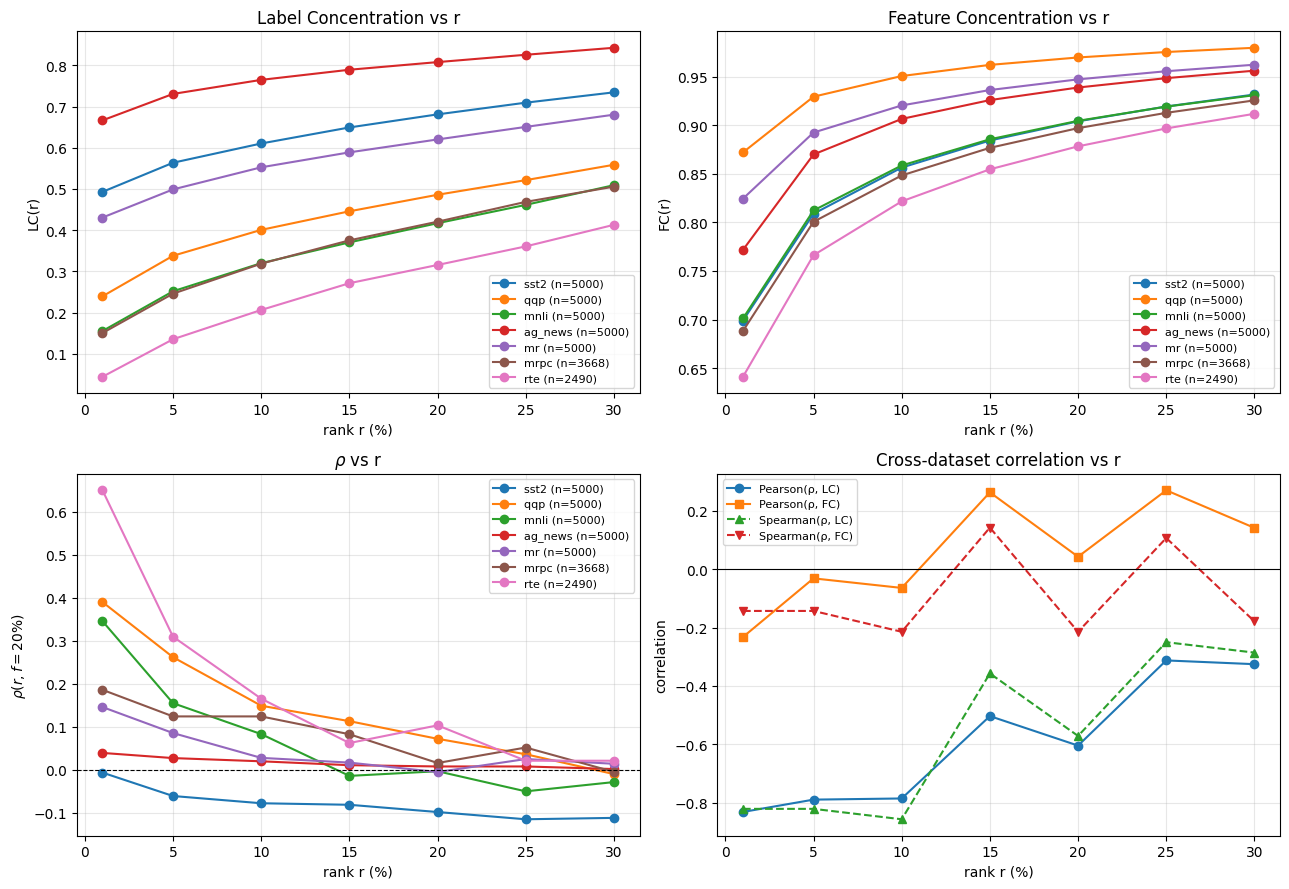

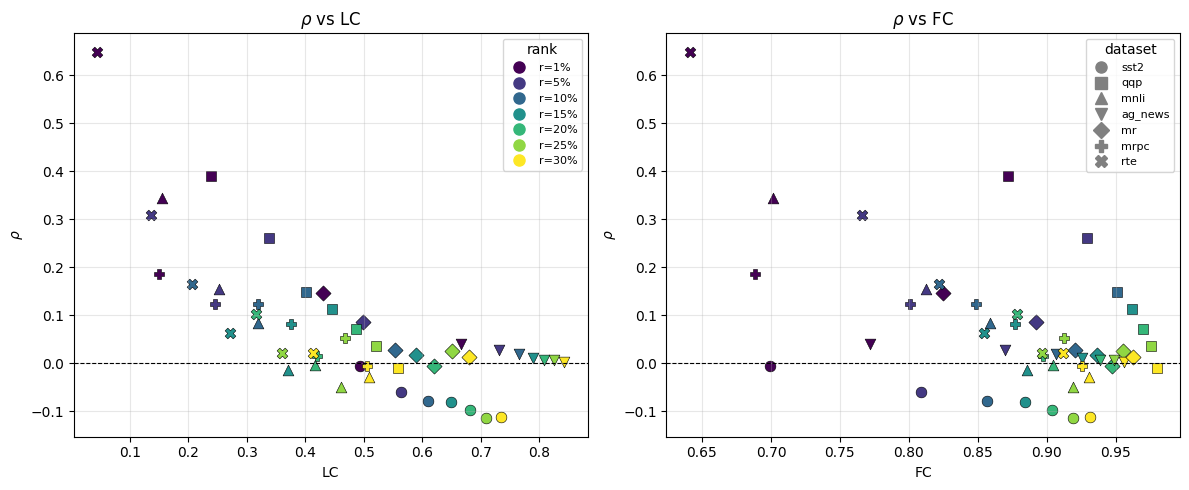

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------------
# 1) Long-format DataFrame
#    ER (Excess Retention) = (acc_eigen - acc_base) / (acc_inv - acc_base)
#                          = 1 - rho
#    ER -> 1  : eigen accuracy ~ inv accuracy (perfect retention)
#    ER -> 0  : eigen accuracy ~ chance baseline
# ------------------------------------------------------------------
rows = []
for ds in DATASETS:
    acc_base = ACC_BASE[ds]
    acc_inv  = ACC_INV_F30[ds]
    for r in R_VALUES:
        entry = PER_RANK[ds][r]
        acc_e = entry["acc_eigen_f30"]
        lc    = entry["LC"]
        fc    = entry["FC"]
        denom = acc_inv - acc_base
        ER    = (acc_e - acc_base) / denom if denom != 0 else float("nan")
        rows.append({
            "dataset": ds, "num_train_dp": NUM_TRAIN_DP[ds], "r": r,
            "acc_base": acc_base, "acc_inv_f30": acc_inv,
            "acc_eigen_f30": acc_e, "LC": lc, "FC": fc, "ER": ER,
        })
df = pd.DataFrame(rows)

# ------------------------------------------------------------------
# 2) Cross-dataset correlations per r  (ER vs LC / FC)
# ------------------------------------------------------------------
CORR = {}
for r in R_VALUES:
    sub = df[df["r"] == r]
    p_lc, _ = pearsonr(sub["ER"],  sub["LC"])
    p_fc, _ = pearsonr(sub["ER"],  sub["FC"])
    s_lc, _ = spearmanr(sub["ER"], sub["LC"])
    s_fc, _ = spearmanr(sub["ER"], sub["FC"])
    CORR[r] = {"pearson_LC": p_lc, "pearson_FC": p_fc,
               "spearman_LC": s_lc, "spearman_FC": s_fc}
corr_df = pd.DataFrame(CORR).T.rename_axis("r").reset_index()

# ------------------------------------------------------------------
# 3) Print tables
# ------------------------------------------------------------------
print("=" * 72)
print("Per-(dataset, r) table")
print("=" * 72)
pivot_cols = ["acc_eigen_f30", "LC", "FC", "ER"]
for col in pivot_cols:
    print(f"\n[{col}]")
    print(df.pivot(index="dataset", columns="r", values=col)
            .reindex(DATASETS).round(4).to_string())

print("\n" + "=" * 72)
print("Cross-dataset correlations (ER vs LC / FC) per r")
print("=" * 72)
print(corr_df.round(4).to_string(index=False))

# ------------------------------------------------------------------
# 4) Plots (4-panel)
# ------------------------------------------------------------------
fig1, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) LC(r) per dataset
ax = axes[0, 0]
for ds in DATASETS:
    sub = df[df["dataset"] == ds].sort_values("r")
    ax.plot(sub["r"], sub["LC"], marker="o",
            label=f"{ds} (n={NUM_TRAIN_DP[ds]})")
ax.set_xlabel("rank r (%)"); ax.set_ylabel("LC(r)")
ax.set_title("Label Concentration vs r"); ax.grid(alpha=.3)
ax.legend(fontsize=8)

# (b) FC(r) per dataset
ax = axes[0, 1]
for ds in DATASETS:
    sub = df[df["dataset"] == ds].sort_values("r")
    ax.plot(sub["r"], sub["FC"], marker="o",
            label=f"{ds} (n={NUM_TRAIN_DP[ds]})")
ax.set_xlabel("rank r (%)"); ax.set_ylabel("FC(r)")
ax.set_title("Feature Concentration vs r"); ax.grid(alpha=.3)
ax.legend(fontsize=8)

# (c) ER(r) per dataset
ax = axes[1, 0]
for ds in DATASETS:
    sub = df[df["dataset"] == ds].sort_values("r")
    ax.plot(sub["r"], sub["ER"], marker="o",
            label=f"{ds} (n={NUM_TRAIN_DP[ds]})")
ax.axhline(1, color="k", lw=.8, ls="--")
ax.set_xlabel("rank r (%)"); ax.set_ylabel("ER(r, f=20%)")
ax.set_title("ER vs r"); ax.grid(alpha=.3)
ax.legend(fontsize=8)

# (d) Pearson/Spearman of (ER, LC) and (ER, FC) vs r
ax = axes[1, 1]
ax.plot(corr_df["r"], corr_df["pearson_LC"],  marker="o", label="Pearson(ER, LC)")
ax.plot(corr_df["r"], corr_df["pearson_FC"],  marker="s", label="Pearson(ER, FC)")
ax.plot(corr_df["r"], corr_df["spearman_LC"], marker="^", ls="--", label="Spearman(ER, LC)")
ax.plot(corr_df["r"], corr_df["spearman_FC"], marker="v", ls="--", label="Spearman(ER, FC)")
ax.axhline(0, color="k", lw=.8)
ax.set_xlabel("rank r (%)"); ax.set_ylabel("correlation")
ax.set_title("Cross-dataset correlation vs r")
ax.grid(alpha=.3); ax.legend(fontsize=8)

plt.tight_layout()
fig1.savefig("lc_fc_analysis_panel_f30.pdf", bbox_inches="tight")
fig1.savefig("lc_fc_analysis_panel_f30.png", bbox_inches="tight", dpi=200)
plt.show()

# ------------------------------------------------------------------
# 5) Scatter: ER vs LC / FC, colored by r
# ------------------------------------------------------------------
fig2, axes = plt.subplots(1, 2, figsize=(12, 5))
cmap = plt.get_cmap("viridis")
colors = {r: cmap(i / (len(R_VALUES) - 1)) for i, r in enumerate(R_VALUES)}
markers = ["o", "s", "^", "v", "D", "P", "X"]
marker_of = {ds: markers[i % len(markers)] for i, ds in enumerate(DATASETS)}

for xcol, ax, title in [("LC", axes[0], "ER vs LC"),
                        ("FC", axes[1], "ER vs FC")]:
    for r in R_VALUES:
        sub = df[df["r"] == r]
        for _, row in sub.iterrows():
            ax.scatter(row[xcol], row["ER"],
                       color=colors[r], marker=marker_of[row["dataset"]],
                       s=60, edgecolor="k", linewidth=.4)
    ax.set_xlabel(xcol); ax.set_ylabel("ER")
    ax.set_title(title); ax.grid(alpha=.3)
    ax.axhline(1, color="k", lw=.8, ls="--")

# shared legend
from matplotlib.lines import Line2D
r_handles  = [Line2D([0], [0], marker="o", color=colors[r], lw=0,
                     markersize=8, label=f"r={r}%") for r in R_VALUES]
ds_handles = [Line2D([0], [0], marker=marker_of[ds], color="gray", lw=0,
                     markersize=8, label=ds) for ds in DATASETS]
axes[0].legend(handles=r_handles,  loc="best", fontsize=8, title="rank")
axes[1].legend(handles=ds_handles, loc="best", fontsize=8, title="dataset")
plt.tight_layout()
fig2.savefig("lc_fc_scatter_f30.pdf", bbox_inches="tight")
fig2.savefig("lc_fc_scatter_f30.png", bbox_inches="tight", dpi=200)
plt.show()
